# Medical Knowledge in LLMs: Physiological and Treatment Violations

LLMs are being incorporated in health related contexts expeditiously whether in symptom checkers or as decision support tools. However, despite their fluent output it still remains unclear whether these models understand medical cause and effect relationships or simply reproduce patterns from training data. This project will evaluate LLM's sensitivity to two foundational forms of medical knowledge.
1. Basic physiological principles, for instance what specific organs do.
2. Clinical treatment mechanisms, such as how these medications work.

These areas relate to almost all medical reasoning tasks. If an LLM were to fail at this level, it will signal deeper limitations in its ability to support safe healthcare decision making.

By comparing the surprisal responses to correct and incorrect statements across the models, this project will access whether LLMs encode meaningful representations of medical knowledge.

# Research Question:

Are LLMs sensitive to physiological impossibilities and incorrect treatment mechanisms?


---



*   will the models show a higher surprisal for incorrect medical statements compared to the correct ones, how will this sensitivity differ across the categories




# Method:

For the model, I will create two seperate categories:

1.   Category 1 - Physiological Impossibilites
2.   Category 2 - Treatment mechanism violations

In each category it will consist of 10 minimal pairs, 20 total, differing only in the medically critical phrase.

I will then be using three different models, GPT-2, GPT-Neo, and Pythia-1.4b to evaluate the models surprisal rates to each category. Additionally I will be using GPT-5.1 as a qualitiative tool to analyze its surprisal rates since testing it on such a model that requires billions of parameters will destroy my computer.  



## Stimuli Table:

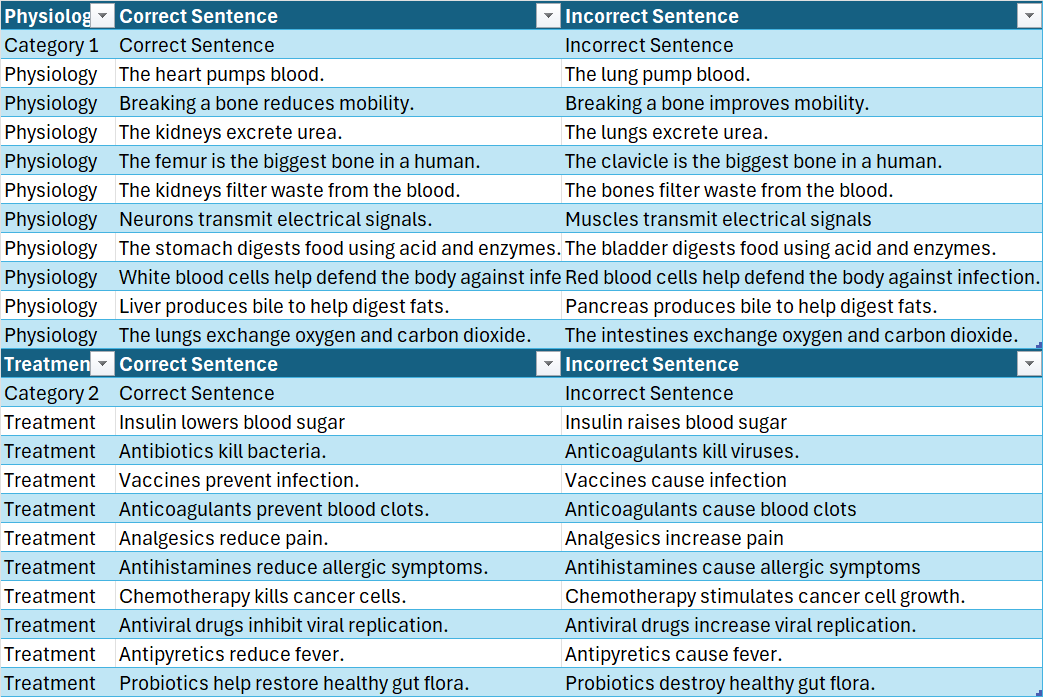

This stimuli table contains a table seperated by the two categories, physiology and treatment, with 10 minimal pairs in each category. The first statement represents the correct statement, and the second statement represents as the incorrect statement. For instance, in Physiology: we have the first statement 'The heart pumps blood' represented as the correct statement and then the preceding one 'The lung pump blood' as we know the lungs are in charge of gas exchange.

## Limitations:

Though the stimuli were designed as minimal pairs, a few potential confounds can influence the surprisal results independently of the intended medical manipulation. The differences in tokenization across the models used may cause the critical words to be split into different token units, and effect by artificially inflating or reducing the surprisal. Additionally, the sentence length and structure vary slightly across some pairs, and can change surprisal because longer contexts provide more predictive information. Furthermore, using verbs such as 'reduces','improves', or 'causes' can introduce smenatic priming effects that will bias the model's expectations toward positive vs negative outcomes independent of medical knowledge. Lastly, The stimuli rely on textbook-style medical facts, meaning that strong model performance can reflect memorization of common co-occurrence patterns whether from training data or genuine understanding; therefore, the design cannot distinguish if the model has medical reasoning or are just reproducing frequent linguistic regularities.The factors may introduce noise into the results and should be controlled more strictly in future stimulus design.

## Model GPT-2:

I will be using GPT-2 as my first model to measure the surprisal rates between the treatment and physiology category.

In [1]:
!pwd

/workspaces/LLM-Medical-Project


In [2]:
%pip install transformers
%pip install torch
%pip install pandas
%pip install matplotlib
%pip install transformers accelerate sentencepiece
%pip install ipywidgets
%pip install pyhton -m


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 25.3 -> 26.0.1
[noti

In [3]:
import torch
import numpy as np
from transformers import GPT2Tokenizer, GPT2LMHeadModel
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
#defining the surprisal function
def surprisal(p):
  return -np.log2(p)

#Loading model and tokenizer
model_name = 'gpt2'
tokenizer = GPT2Tokenizer.from_pretrained(model_name)
model = GPT2LMHeadModel.from_pretrained(model_name)
model.eval()

#creating the minimal pairs
stimuli = [
    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'heart pumps blood.',
     'incorrect_unseen': 'lung pumps blood.'},

    {'category': 'Physiology',
     'seen': 'Breaking a bone',
     'correct_unseen': 'reduces mobility.',
     'incorrect_unseen': 'improves mobility.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen': 'Kidneys excrete urea.',
     'incorrect_unseen': 'Lungs excrete urea.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'femur is the biggest bone in a human.',
     'incorrect_unseen': 'clavicle is the biggest bone in a human.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'kidneys filter waste from the blood.',
     'incorrect_unseen': 'bones filter waste from the blood.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen': 'Neurons transmit electrical signals.',
     'incorrect_unseen':'Muscles transmit electrical signals.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen':'stomach digests food using acid and enzymes.',
     'incorrect_unseen': 'bladder digests food using acid and enzymes.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen':'White Blood cells help defend the body against infection.',
     'incorrect_unseen': 'Red Blood cells help defend the body against infection.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen':'Liver produces bile to help digest fats.',
     'incorrect_unseen':'Pancreas produces bile to help digest fats.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen':'lungs exchange oxygen and carbon dioxide.',
     'incorrect_unseen':'intestines exchange oxygen and carbon dioxide.'},

    {'category': 'Treatment',
     'seen': 'Insulin',
     'correct_unseen': 'lowers blood sugar',
     'incorrect_unseen': 'raises blood sugar'},

    {'category': 'Treatment',
     'seen': '',
     'correct_unseen': 'Antibiotics kill bacteria.',
     'incorrect_unseen': 'Anticoagulants kill bacteria.'},

    {'category': 'Treatment',
     'seen': 'Vaccines',
     'correct_unseen': 'prevent infection.',
     'incorrect_unseen': 'cause infection.'},

    {'category': 'Treatment',
     'seen': 'Anticoagulants',
     'correct_unseen':'prevent blood clots.',
     'incorrect_unseen':'cause blood clots.'},

    {'category': 'Treatment',
     'seen': 'Analgesics',
     'correct_unseen': 'reduce pain.',
     'incorrect_unseen': 'increase pain.'},

    {'category': 'Treatment',
     'seen': 'Antihistamines',
     'correct_unseen': 'reduce allergic symptoms.',
     'incorrect_unseen': 'cause allergic symptoms.'},

    {'category': 'Treatment',
     'seen': 'Chemotherapy',
     'correct_unseen': 'kills cancer cells.',
     'incorrect_unseen': 'stimulates cancer cells.'},

    {'category': 'Treatment',
     'seen': 'Antiviral drugs',
     'correct_unseen': 'inhibit viral replication.',
     'incorrect_unseen': 'increase viral replication.'},

    {'category': 'Treatment',
     'seen': 'Antipyretics',
     'correct_unseen': 'reduce fever.',
     'incorrect_unseen': 'Antipyretics cause fever.'},

    {'category': 'Treatment',
     'seen': 'Probiotics help',
     'correct_unseen': 'restore healthy gut flora.',
     'incorrect_unseen': 'help destroy healthy gut flora.'}

]


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
#Calculating sequence probability
def seq_prob(model, tokenizer, seen, unseen):
  #getting ids for tokens
  if seen: # if seen is not an empty string
      input_ids = tokenizer.encode(seen, return_tensors='pt')
  else:
      # If 'seen' is empty, use the tokenizer's EOS token as the initial context
      # This allows the model to start generating from a known point.
      input_ids = torch.tensor([[tokenizer.eos_token_id]], dtype=torch.long)

  unseen_ids = tokenizer.encode(unseen)

  #creating loop for unseen tokens and storing log prob
  log_prob = []
  for unseen_id in unseen_ids:
    with torch.no_grad():
      logits = model(input_ids).logits
    #Get next token prediction logits
    next_token_logits = logits[0,-1]
    next_token_prob = torch.softmax(next_token_logits, 0)

    #get prob for relevant token in unseen strings and store it
    # Ensure unseen_id is within the valid range of next_token_prob
    if unseen_id < len(next_token_prob):
        prob = next_token_prob[unseen_id]
        if prob == 0: # Avoid log(0) which would be -inf
            log_prob.append(torch.tensor(float('-inf')))
        else:
            log_prob.append(torch.log(prob))
    else:
        # Handle cases where unseen_id is out of vocab for next_token_prob
        log_prob.append(torch.tensor(float('-inf'))) # Assign a very low probability

    #input tokens incrementally to input
    input_ids = torch.cat((input_ids, torch.tensor([[unseen_id]], dtype=torch.long)), 1)

  #adding log probs together to get total
  total_log_prob = sum(log_prob)

  #exponentiate to return to probabilities
  total_prob = torch.exp(total_log_prob)
  return total_prob


In [6]:
#computing the surprisal
result = []
#probability of the whole correct phrase given the context
for index, item in enumerate(stimuli):
  correct_prob = seq_prob(model, tokenizer,
                          item['seen'],
                          item['correct_unseen']
                          )
#probability of the whole incorrect phrase
  incorrect_prob = seq_prob(model, tokenizer,
                            item['seen'],
                            item['incorrect_unseen']
                            )

#shows surprisal rate for each correct statement
  result.append({
      'category': item['category'],
      'item_id': index,
      'seen': item['seen'],
      'item': item['correct_unseen'],
      'condition': 'Correct',
      'surprisal': surprisal(correct_prob)
  })
#shows surprisal rate for each incorrect statement
  result.append({
      'category': item['category'],
      'item_id': index,
      'seen': item['seen'],
      'item': item['incorrect_unseen'],
      'condition': 'Incorrect',
      'surprisal': surprisal(incorrect_prob)
   })

results_dfgpt2 = pd.DataFrame(result)
print('\n')
print(results_dfgpt2.to_string(index=False))

/tmp/ipykernel_1972/162789628.py:3: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log2(p)




  category  item_id            seen                                                      item condition       surprisal
Physiology        0             The                                        heart pumps blood.   Correct tensor(45.5224)
Physiology        0             The                                         lung pumps blood. Incorrect tensor(64.7729)
Physiology        1 Breaking a bone                                         reduces mobility.   Correct tensor(60.5815)
Physiology        1 Breaking a bone                                        improves mobility. Incorrect tensor(51.3325)
Physiology        2                                                     Kidneys excrete urea.   Correct tensor(51.6810)
Physiology        2                                                       Lungs excrete urea. Incorrect tensor(54.6039)
Physiology        3             The                     femur is the biggest bone in a human.   Correct tensor(85.3060)
Physiology        3             The   

Using the data from above, it can be transformedf into a graph where we can compare the surprisal of the word that completes the correct statement. With a paired plot graph, it will further vizualise how insignitificant the difference in surprisal was for each pair.

## Graph 1: Paired Plot

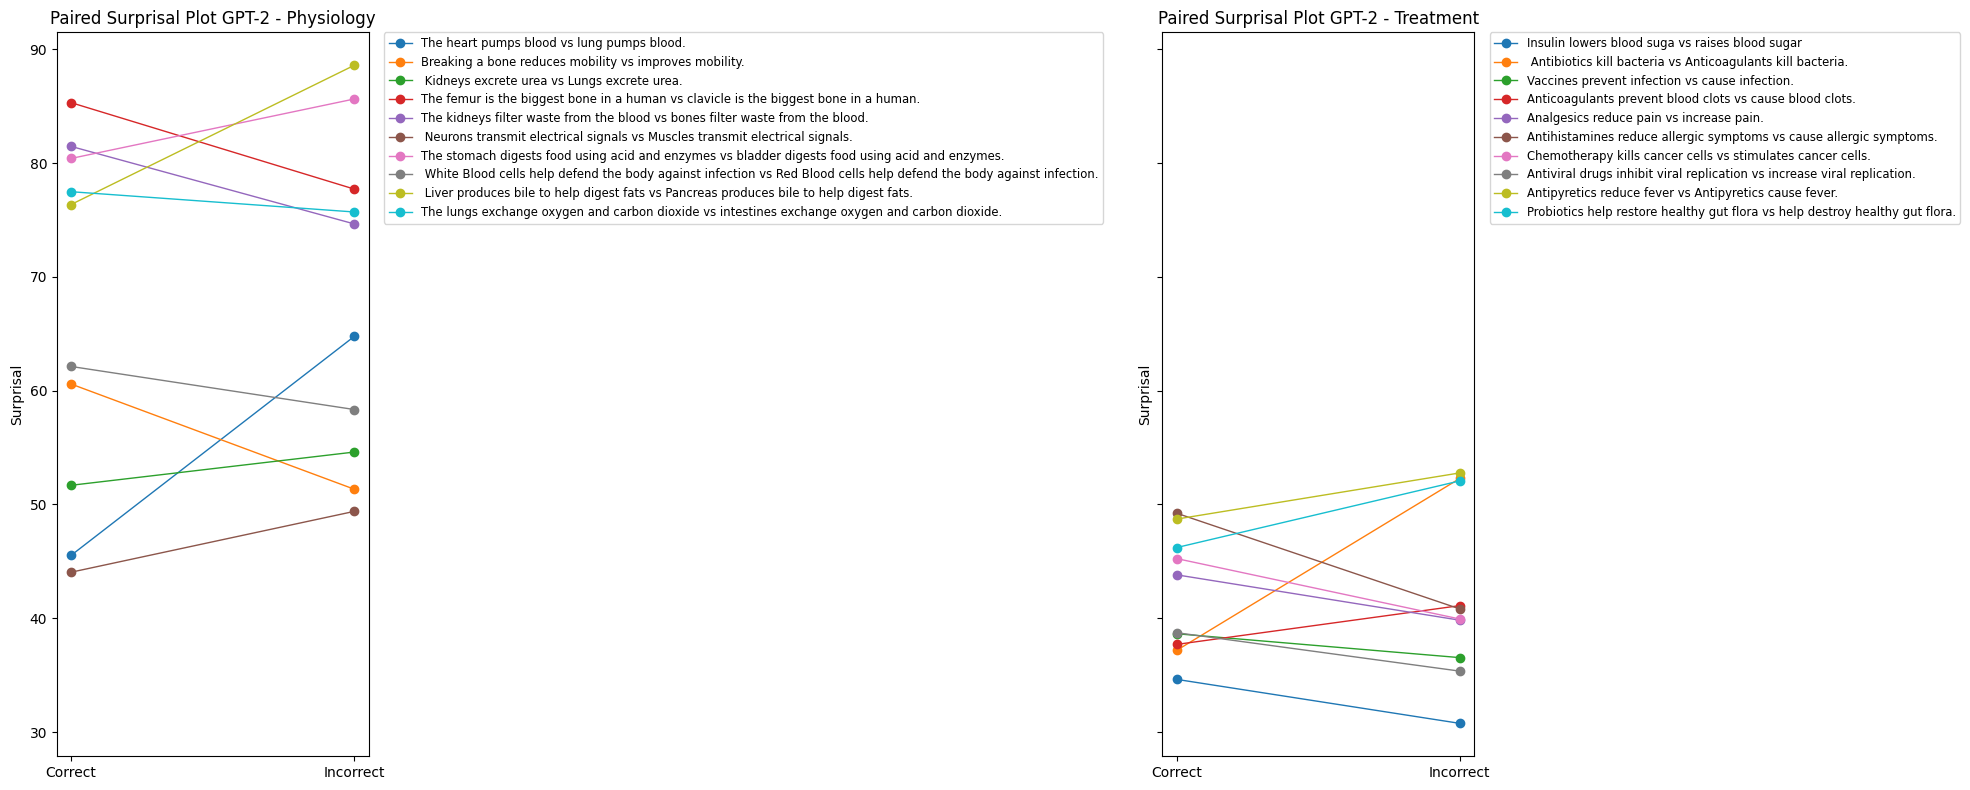

In [7]:
#putting results function into a paired surprisal plot

df_gpt2 = results_dfgpt2 # Assign results_df to df
phy_data = df_gpt2[df_gpt2['category']=='Physiology']
treat_data = df_gpt2[df_gpt2['category']=='Treatment']

# Create a mapping from item_id to original stimuli for labels
# The 'index' in the loop for generating 'result' is the item_id.
# So, we can directly use 'item_id' from results_df to map to 'stimuli'.

fig, axes = plt.subplots(1,2, figsize = (20,8), sharey=True) # Increased figsize for larger graph

# Physiology Plot
axes[0].set_title('Paired Surprisal Plot GPT-2 - Physiology')
axes[0].set_ylabel('Surprisal')
axes[0].set_xticks([0,1])
axes[0].set_xticklabels(['Correct','Incorrect'])
for item_id, row in phy_data.pivot(index='item_id', columns='condition', values='surprisal').iterrows():
    original_stimulus_entry = stimuli[item_id]
    label_text = f"{original_stimulus_entry['seen']} {original_stimulus_entry['correct_unseen'][:-1]} vs {original_stimulus_entry['incorrect_unseen']}"
    axes[0].plot(['Correct','Incorrect'], row.values, marker='o', linewidth=1, label=label_text)
axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0., fontsize='small') # Position legend outside and make font smaller

# Treatment Plot
axes[1].set_title('Paired Surprisal Plot GPT-2 - Treatment')
axes[1].set_ylabel('Surprisal')
axes[1].set_xticks([0,1])
axes[1].set_xticklabels(['Correct','Incorrect'])
for item_id, row in treat_data.pivot(index='item_id', columns='condition', values='surprisal').iterrows():
    # For treatment items, item_id in treat_data (0-9) maps to stimuli[10-19]
    original_stimulus_entry = stimuli[item_id]
    label_text = f"{original_stimulus_entry['seen']} {original_stimulus_entry['correct_unseen'][:-1]} vs {original_stimulus_entry['incorrect_unseen']}"
    axes[1].plot(['Correct','Incorrect'], row.values, marker='o', linewidth=1, label=label_text)
axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), borderaxespad=0., fontsize='small') # Make font smaller

plt.tight_layout()
plt.show()

The graph above compares the possible outcomes for each individual statement in both the Physiology, and Treatment category for GPT-2. The results shown are a dramatic difference, in both catgegories.

## Graph 2: Bar Chart

As an additional chart I will also be using a bar chart to visualize my data to show the general comparison

In [8]:
import pandas as pd

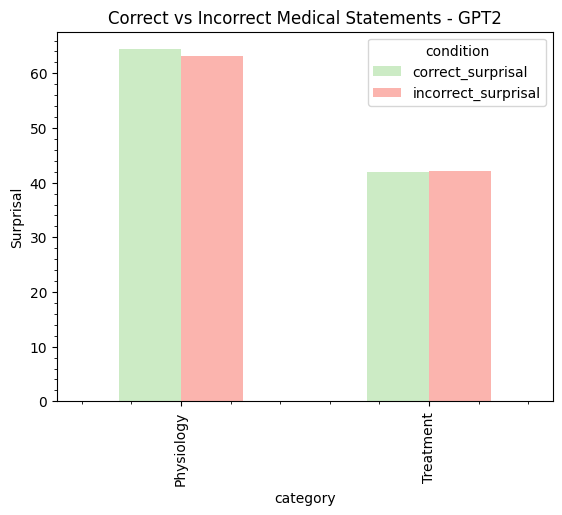

In [9]:
#putting results function into a bar chart

df_gpt2 = pd.DataFrame(result)
df_gpt2['model'] = 'GPT-2'

# Pivot the DataFrame to get 'correct_surprisal' and 'incorrect_surprisal' as separate columns
pivoted_df = df_gpt2.pivot_table(index=['category', 'seen'], columns='condition', values='surprisal').reset_index()
pivoted_df.rename(columns={'Correct': 'correct_surprisal', 'Incorrect': 'incorrect_surprisal'}, inplace=True)

#Setting color theme to pastel
cmap = plt.get_cmap('Pastel1')
colors = cmap.colors
#creating visualization
pivoted_df.groupby('category')[['correct_surprisal','incorrect_surprisal']].mean().plot(
    kind='bar',
    color = [colors[2], colors[0]]
    )
plt.minorticks_on()
plt.ylabel('Surprisal')
plt.title('Correct vs Incorrect Medical Statements - GPT2')
plt.show()


The graph above compares the surprisal rates of both averages of incorrect and correct statements in Physiology and Treatment, showing once again an insignificant difference between either category.

## Analysis on Model 1 - GPT2:

Based off results, the model barely shows differentiation between correct and incorrect medical statements. In the physiology category correct statements have an average surprisal around 66 while incorrect ones are around 64, the difference is incredibly small, suggesting that GPT2 has no meaningful physiological knowledge. In the treatment category, the gap is not visable, both correct and incorrect statements are around 42 surprisal. These extremely small, almost non-existent differences demonstrate that GPT-2 is not evaluating statements based on medical plausibility but instead on surface-level cues in text that the model was trained on.

In terms of a cognitive science perspective, the results highlight the limits of GPT-2 as a predictive LLM. Surprisal reflects prediction error, and having a low surprisal means the model finds the preceding statement expected, and a high surprisal means it was unexpected. Instead, GPT2 relies almost entirely on shallow co-occurrence patterns; correct physiological statements such as 'the heart pumps blood' occur frequently in natural text, while medically impossible statements occur far less often. Additionally, a key factor is that GPT-2 was trained on a relatively small, general corpus compared to modern LLMs, so it encountered limited curated medical material. This becomes visable when the model assigns nearly equal surprisal rates to correct and incorrect statements. An incorrect statement like 'bones filter waste' may not be marked unexpected if its surface form resembles other well formed english sentences, demonstrating GPT2 knowledge is associative rather than causal.

To conclude, the model's medical knowledge is heavily shaped by training data frequency instead of domain knowledge.



## Model 2:  GPT-Neo

I will next be using GPT-Neo as my second model to measure the surprisal rates between treatment and physiology.

In [10]:
from transformers import AutoTokenizer, AutoModelForCausalLM
#defining the surprisal function
def surprisal(p):
  return -np.log2(p)

#Loading model and tokenizer
model_name = 'EleutherAI/gpt-neo-125M'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

#creating the minimal pairs
stimuli = [
    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'heart pumps blood.',
     'incorrect_unseen': 'lung pumps blood.'},

    {'category': 'Physiology',
     'seen': 'Breaking a bone',
     'correct_unseen': 'reduces mobility.',
     'incorrect_unseen': 'improves mobility.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen': 'Kidneys excrete urea.',
     'incorrect_unseen': 'Lungs excrete urea.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'femur is the biggest bone in a human.',
     'incorrect_unseen': 'clavicle is the biggest bone in a human.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'kidneys filter waste from the blood.',
     'incorrect_unseen': 'bones filter waste from the blood.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen': 'Neurons transmit electrical signals.',
     'incorrect_unseen':'Muscles transmit electrical signals.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen':'stomach digests food using acid and enzymes.',
     'incorrect_unseen': 'bladder digests food using acid and enzymes.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen':'White Blood cells help defend the body against infection.',
     'incorrect_unseen': 'Red Blood cells help defend the body against infection.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen':'Liver produces bile to help digest fats.',
     'incorrect_unseen':'Pancreas produces bile to help digest fats.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen':'lungs exchange oxygen and carbon dioxide.',
     'incorrect_unseen':'intestines exchange oxygen and carbon dioxide.'},

    {'category': 'Treatment',
     'seen': 'Insulin',
     'correct_unseen': 'lowers blood sugar',
     'incorrect_unseen': 'raises blood sugar'},

    {'category': 'Treatment',
     'seen': '',
     'correct_unseen': 'Antibiotics kill bacteria.',
     'incorrect_unseen': 'Anticoagulants kill bacteria.'},

    {'category': 'Treatment',
     'seen': 'Vaccines',
     'correct_unseen': 'prevent infection.',
     'incorrect_unseen': 'cause infection.'},

    {'category': 'Treatment',
     'seen': 'Anticoagulants',
     'correct_unseen':'prevent blood clots.',
     'incorrect_unseen':'cause blood clots.'},

    {'category': 'Treatment',
     'seen': 'Analgesics',
     'correct_unseen': 'reduce pain.',
     'incorrect_unseen': 'increase pain.'},

    {'category': 'Treatment',
     'seen': 'Antihistamines',
     'correct_unseen': 'reduce allergic symptoms.',
     'incorrect_unseen': 'cause allergic symptoms.'},

    {'category': 'Treatment',
     'seen': 'Chemotherapy',
     'correct_unseen': 'kills cancer cells.',
     'incorrect_unseen': 'stimulates cancer cells.'},

    {'category': 'Treatment',
     'seen': 'Antiviral drugs',
     'correct_unseen': 'inhibit viral replication.',
     'incorrect_unseen': 'increase viral replication.'},

    {'category': 'Treatment',
     'seen': 'Antipyretics',
     'correct_unseen': 'reduce fever.',
     'incorrect_unseen': 'Antipyretics cause fever.'},

    {'category': 'Treatment',
     'seen': 'Probiotics help',
     'correct_unseen': 'restore healthy gut flora.',
     'incorrect_unseen': 'help destroy healthy gut flora.'}
]

Loading weights:   0%|          | 0/160 [00:01<?, ?it/s]

GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125M
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [11]:
#Calculating sequence probability
def seq_prob(model, tokenizer, seen, unseen):
  #getting ids for tokens
  if seen: # if seen is not an empty string
      input_ids = tokenizer.encode(seen, return_tensors='pt')
  else:
      # If 'seen' is empty, use the tokenizer's EOS token as the initial context
      # This allows the model to start generating from a known point.
      input_ids = torch.tensor([[tokenizer.eos_token_id]], dtype=torch.long)

  unseen_ids = tokenizer.encode(unseen)

  #creating loop for unseen tokens and storing log prob
  log_prob = []
  for unseen_id in unseen_ids:
    with torch.no_grad():
      logits = model(input_ids).logits
    #Get next token prediction logits
    next_token_logits = logits[0,-1]
    next_token_prob = torch.softmax(next_token_logits, 0)

    #get prob for relevant token in unseen strings and store it
    # Ensure unseen_id is within the valid range of next_token_prob
    if unseen_id < len(next_token_prob):
        prob = next_token_prob[unseen_id]
        if prob == 0: # Avoid log(0) which would be -inf
            log_prob.append(torch.tensor(float('-inf')))
        else:
            log_prob.append(torch.log(prob))
    else:
        # Handle cases where unseen_id is out of vocab for next_token_prob
        log_prob.append(torch.tensor(float('-inf'))) # Assign a very low probability

    #input tokens incrementally to input
    input_ids = torch.cat((input_ids, torch.tensor([[unseen_id]], dtype=torch.long)), 1)

  #adding log probs together to get total
  total_log_prob = sum(log_prob)

  #exponentiate to return to probabilities
  total_prob = torch.exp(total_log_prob)
  return total_prob

In [12]:
#computing the surprisal
result = []
#probability of the whole correct phrase given the context
for index, item in enumerate(stimuli):
  correct_prob = seq_prob(model, tokenizer,
                          item['seen'],
                          item['correct_unseen']
                          )
#probability of the whole incorrect phrase
  incorrect_prob = seq_prob(model, tokenizer,
                            item['seen'],
                            item['incorrect_unseen']
                            )

#shows surprisal rate for each correct statement
  result.append({
      'category': item['category'],
      'item_id': index,
      'seen': item['seen'],
      'item': item['correct_unseen'],
      'condition': 'Correct',
      'surprisal': surprisal(correct_prob)
  })
#shows surprisal rate for each incorrect statement
  result.append({
      'category': item['category'],
      'item_id': index,
      'seen': item['seen'],
      'item': item['incorrect_unseen'],
      'condition': 'Incorrect',
      'surprisal': surprisal(incorrect_prob)
   })

results_dfgptneo = pd.DataFrame(result)
print('\n')
print(results_dfgptneo.to_string(index=False))

/tmp/ipykernel_1972/324902309.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log2(p)




  category  item_id            seen                                                      item condition       surprisal
Physiology        0             The                                        heart pumps blood.   Correct tensor(51.9541)
Physiology        0             The                                         lung pumps blood. Incorrect tensor(70.5409)
Physiology        1 Breaking a bone                                         reduces mobility.   Correct tensor(51.7454)
Physiology        1 Breaking a bone                                        improves mobility. Incorrect tensor(46.9249)
Physiology        2                                                     Kidneys excrete urea.   Correct tensor(52.0330)
Physiology        2                                                       Lungs excrete urea. Incorrect tensor(55.5295)
Physiology        3             The                     femur is the biggest bone in a human.   Correct tensor(78.6296)
Physiology        3             The   

Using the data from above, it can be transformed into a graph where we can compare the surprisal of the word that completes the correct statement. With a paired plot graph, it will further vizualise how insignitificant the difference in surprisal was for each pair.

## Graph 1: Paired Plot

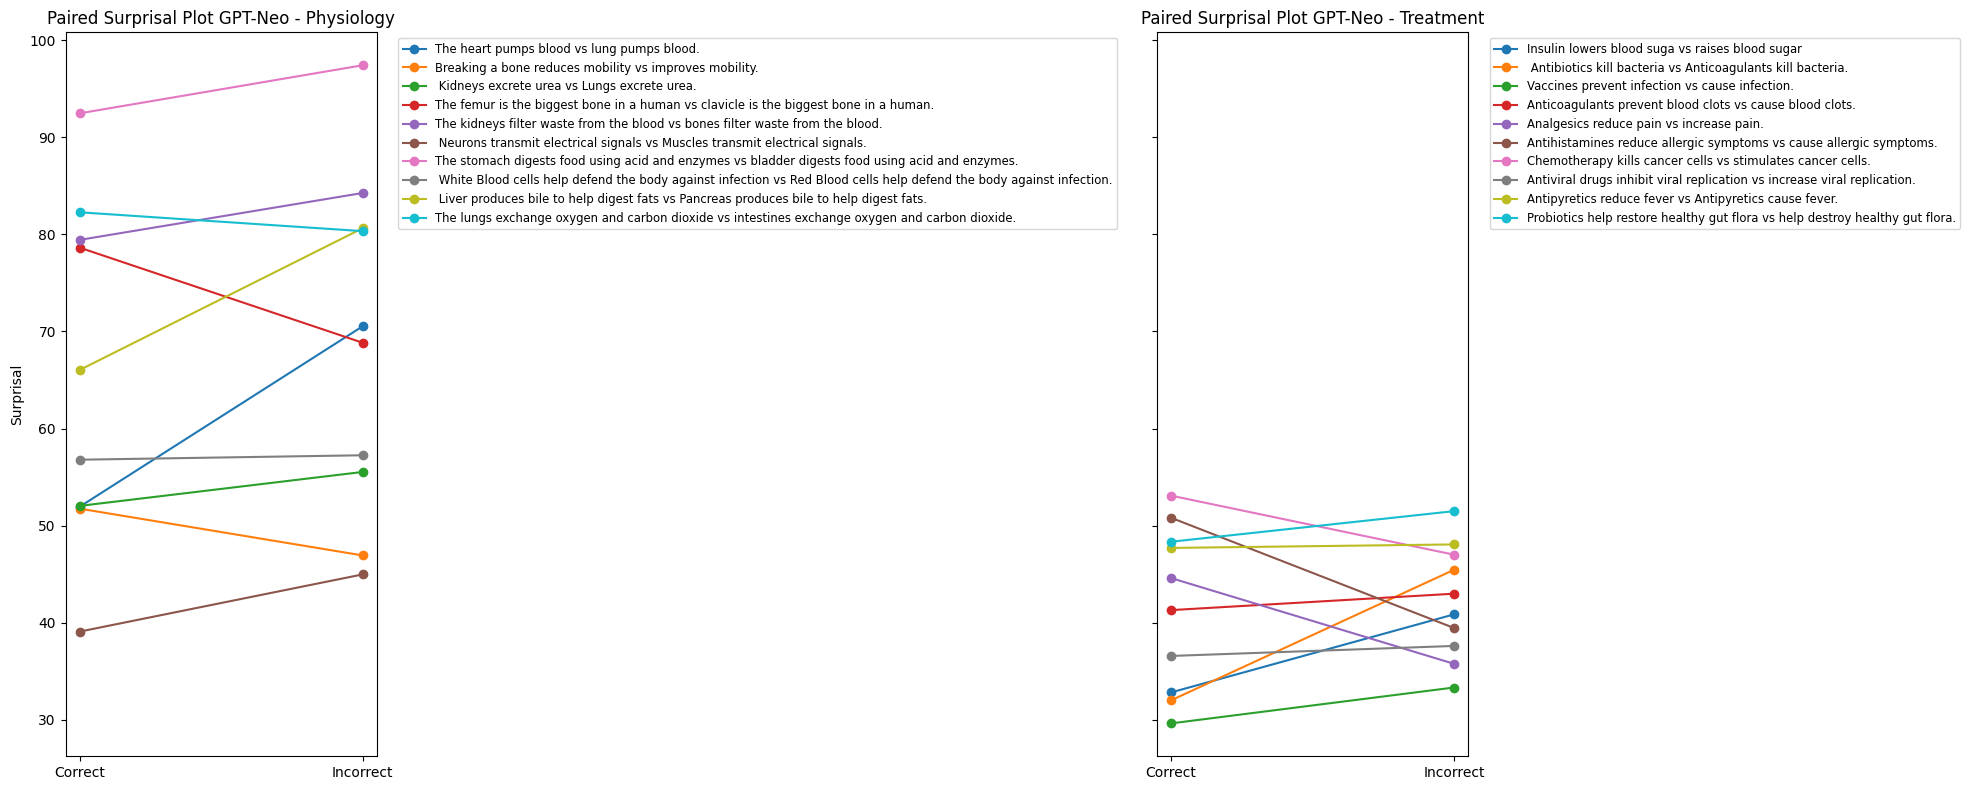

In [13]:
#creating paired plot graph
df_gptneo = results_dfgptneo

# Split categories
phy_data = df_gptneo[df_gptneo['category'] == 'Physiology']
treat_data = df_gptneo[df_gptneo['category'] == 'Treatment']

# Pivot
phy_pivot = phy_data.pivot(index='item_id', columns='condition', values='surprisal')
treat_pivot = treat_data.pivot(index='item_id', columns='condition', values='surprisal')

# Normalize column labels
phy_pivot.columns = phy_pivot.columns.str.lower().str.strip()
treat_pivot.columns = treat_pivot.columns.str.lower().str.strip()

# Prepare figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

x = [0, 1]
labels = ['Correct', 'Incorrect']

#PHYSIOLOGY PLOT

axes[0].set_title('Paired Surprisal Plot GPT-Neo - Physiology')
axes[0].set_ylabel('Surprisal')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)

for item_id, row in phy_pivot.iterrows():
    original = stimuli[item_id]
    label = (
        f"{original['seen']} "
        f"{original['correct_unseen'][:-1]} vs "
        f"{original['incorrect_unseen']}"
    )

    axes[0].plot(x, [row['correct'], row['incorrect']], marker='o', label=label)

axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')


#TREATMENT PLOT

axes[1].set_title('Paired Surprisal Plot GPT-Neo - Treatment')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

for item_id, row in treat_pivot.iterrows():
    original = stimuli[item_id]
    label = (
        f"{original['seen']} "
        f"{original['correct_unseen'][:-1]} vs "
        f"{original['incorrect_unseen']}"
    )

    axes[1].plot(x, [row['correct'], row['incorrect']], marker='o', label=label)

axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')

plt.tight_layout()
plt.show()

The graph above compares the possible outcomes for each individual statement in both the Physiology, and Treatment category for GPT-Neo. The results shown are not a dramatic difference but a bit better in comparison to GPT-2.

## Graph 2: Bar Chart

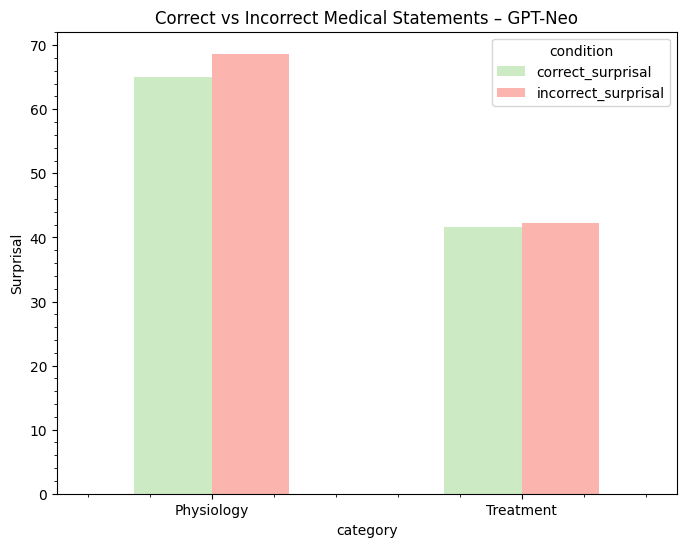

In [14]:
#putting results function into a bar chart

df = pd.DataFrame(result)
df_gptneo = df.copy()
df_gptneo['model'] = 'GPT-Neo'

# Pivot: one row per item
pivoted_df = df_gptneo.pivot_table(
    index=['category','item_id'],
    columns='condition',
    values='surprisal'
).reset_index()

# Normalize and rename columns
pivoted_df.columns = pivoted_df.columns.str.lower().str.strip()
pivoted_df.rename(columns={'correct':'correct_surprisal', 'incorrect':'incorrect_surprisal'}, inplace=True)

# Now can group and plot
category_means = pivoted_df.groupby('category')[['correct_surprisal','incorrect_surprisal']].mean()

# Plot
cmap = plt.get_cmap('Pastel1')
colors = cmap.colors

category_means.plot(
    kind='bar',
    color=[colors[2], colors[0]],
    figsize=(8,6)
)

plt.minorticks_on()
plt.ylabel('Surprisal')
plt.title('Correct vs Incorrect Medical Statements – GPT-Neo')
plt.xticks(rotation=0)
plt.show()

The graph above compares the surprisal rates of both averages of incorrect and correct statements in Physiology and Treatment, showing a bit more of a difference in comparison to GPT-2.

## Analysis on GPT-Neo:

The model highlights clearer differentiation between correct and incorrect medical statements in comparison to GPT 2, demonstrating a small improvement in factual sensitivity. In the physiology category, correct statements have a lower surprisal where whereas incorrect statements have consistently higher surprisal, showing that the model is partially sensitive to violations of biological structure and function. The treatment category shows a similar but smaller gap, reflecting that it captures some regularities but still lacks strong domain knowledge. This pattern makes sense considering GPT Neo is trained on the pile, which is a big but heterogeneous 800GB corpus. Though larger and more diverse, the pile has wide ranging text including content where medically incorrect statements can appear frequently. Therefore, the results could reflect noise from the uncontrolled variability in its training distribution instead of meaningful medical understanding.

In terms of a cognitive science stand point, these results highlight how GPT-Neo's behavior reflects distributional learning rather than genuine medical reasoning. The model assigning higher surprisal to incorrect statements show that there are some regulariities about how physiological and treatment-related concepts typically co-occur in language. However, the model still relied on associative patterns not mechanistic understanding. It doesn't know why a medical statement is incorrect, it has simply just seen feweer instances of these patterns in its trainig data. While the model performs better than GPT-2, the models knowledge remains correlational rather than conceptual

Overall, the models results highlight that increasing dataset size without increasing model scale or domain curation will not guarantee an improved factual sensitivity.

## Model 3: Pythia-1.4B

Lastly, I will be using Pythia-1.4B as my last model to measure the surprisal rates between treatment and physiology.

In [15]:
from transformers import AutoTokenizer, AutoModelForCausalLM
#defining the surprisal function
def surprisal(p):
  return -np.log2(p)

#Loading model and tokenizer
model_name = 'EleutherAI/pythia-1.4b'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)
model.eval()

#creating the minimal pairs
stimuli = [
    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'heart pumps blood.',
     'incorrect_unseen': 'lung pumps blood.'},

    {'category': 'Physiology',
     'seen': 'Breaking a bone',
     'correct_unseen': 'reduces mobility.',
     'incorrect_unseen': 'improves mobility.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen': 'Kidneys excrete urea.',
     'incorrect_unseen': 'Lungs excrete urea.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'femur is the biggest bone in a human.',
     'incorrect_unseen': 'clavicle is the biggest bone in a human.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen': 'kidneys filter waste from the blood.',
     'incorrect_unseen': 'bones filter waste from the blood.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen': 'Neurons transmit electrical signals.',
     'incorrect_unseen':'Muscles transmit electrical signals.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen':'stomach digests food using acid and enzymes.',
     'incorrect_unseen': 'bladder digests food using acid and enzymes.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen':'White Blood cells help defend the body against infection.',
     'incorrect_unseen': 'Red Blood cells help defend the body against infection.'},

    {'category': 'Physiology',
     'seen': '',
     'correct_unseen':'Liver produces bile to help digest fats.',
     'incorrect_unseen':'Pancreas produces bile to help digest fats.'},

    {'category': 'Physiology',
     'seen': 'The',
     'correct_unseen':'lungs exchange oxygen and carbon dioxide.',
     'incorrect_unseen':'intestines exchange oxygen and carbon dioxide.'},

    {'category': 'Treatment',
     'seen': 'Insulin',
     'correct_unseen': 'lowers blood sugar',
     'incorrect_unseen': 'raises blood sugar'},

    {'category': 'Treatment',
     'seen': '',
     'correct_unseen': 'Antibiotics kill bacteria.',
     'incorrect_unseen': 'Anticoagulants kill bacteria.'},

    {'category': 'Treatment',
     'seen': 'Vaccines',
     'correct_unseen': 'prevent infection.',
     'incorrect_unseen': 'cause infection.'},

    {'category': 'Treatment',
     'seen': 'Anticoagulants',
     'correct_unseen':'prevent blood clots.',
     'incorrect_unseen':'cause blood clots.'},

    {'category': 'Treatment',
     'seen': 'Analgesics',
     'correct_unseen': 'reduce pain.',
     'incorrect_unseen': 'increase pain.'},

    {'category': 'Treatment',
     'seen': 'Antihistamines',
     'correct_unseen': 'reduce allergic symptoms.',
     'incorrect_unseen': 'cause allergic symptoms.'},

    {'category': 'Treatment',
     'seen': 'Chemotherapy',
     'correct_unseen': 'kills cancer cells.',
     'incorrect_unseen': 'stimulates cancer cells.'},

    {'category': 'Treatment',
     'seen': 'Antiviral drugs',
     'correct_unseen': 'inhibit viral replication.',
     'incorrect_unseen': 'increase viral replication.'},

    {'category': 'Treatment',
     'seen': 'Antipyretics',
     'correct_unseen': 'reduce fever.',
     'incorrect_unseen': 'Antipyretics cause fever.'},

    {'category': 'Treatment',
     'seen': 'Probiotics help',
     'correct_unseen': 'restore healthy gut flora.',
     'incorrect_unseen': 'help destroy healthy gut flora.'}

]


Loading weights:   0%|          | 0/292 [00:00<?, ?it/s]

In [16]:
#Calculating sequence probability
def seq_prob(model, tokenizer, seen, unseen):
    #  normalizing spacing so "The" + "heart" becomes "The heart" 
    if seen and seen.strip() != "":
        # add a space before unseen if needed
        if unseen and not unseen.startswith((" ", ".", ",", "!", "?", ";", ":")):
            unseen = " " + unseen
        input_ids = tokenizer.encode(seen, return_tensors="pt", add_special_tokens=False)
    else:
        input_ids = torch.tensor([[tokenizer.eos_token_id]], dtype=torch.long)

    # don't add special tokens to the continuation
    unseen_ids = tokenizer.encode(unseen, add_special_tokens=False)

    total_log_prob = 0.0  # natural log

    with torch.no_grad():
        for uid in unseen_ids:
            logits = model(input_ids).logits
            log_probs = torch.log_softmax(logits[0, -1], dim=-1)
            total_log_prob += float(log_probs[uid])
            input_ids = torch.cat([input_ids, torch.tensor([[uid]], dtype=torch.long)], dim=1)

    # return probability 
    return torch.exp(torch.tensor(total_log_prob))

In [17]:
#computing the surprisal
result = []
#probability of the whole correct phrase given the context
for index, item in enumerate(stimuli):
  correct_surp = seq_prob(model, tokenizer,
                          item['seen'],
                          item['correct_unseen']
                          )
#probability of the whole incorrect phrase
  incorrect_surp = seq_prob(model, tokenizer,
                            item['seen'],
                            item['incorrect_unseen']
                            )

#shows surprisal rate for each correct statement
  result.append({
      'category': item['category'],
      'item_id': index,
      'seen': item['seen'],
      'item': item['correct_unseen'],
      'condition': 'Correct',
      'surprisal': surprisal(correct_surp)
  })
#shows surprisal rate for each incorrect statement
  result.append({
      'category': item['category'],
      'item_id': index,
      'seen': item['seen'],
      'item': item['incorrect_unseen'],
      'condition': 'Incorrect',
      'surprisal': surprisal(incorrect_surp)
   })

results_dfpythia = pd.DataFrame(result)
print('\n')
print(results_dfpythia.to_string(index=False))

/tmp/ipykernel_1972/1018404600.py:4: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  return -np.log2(p)




  category  item_id            seen                                                      item condition       surprisal
Physiology        0             The                                        heart pumps blood.   Correct tensor(26.9012)
Physiology        0             The                                         lung pumps blood. Incorrect tensor(45.5012)
Physiology        1 Breaking a bone                                         reduces mobility.   Correct tensor(24.8809)
Physiology        1 Breaking a bone                                        improves mobility. Incorrect tensor(23.5593)
Physiology        2                                                     Kidneys excrete urea.   Correct tensor(48.8967)
Physiology        2                                                       Lungs excrete urea. Incorrect tensor(54.3772)
Physiology        3             The                     femur is the biggest bone in a human.   Correct tensor(42.2598)
Physiology        3             The   

## Graph 1: Paired Plot Graph

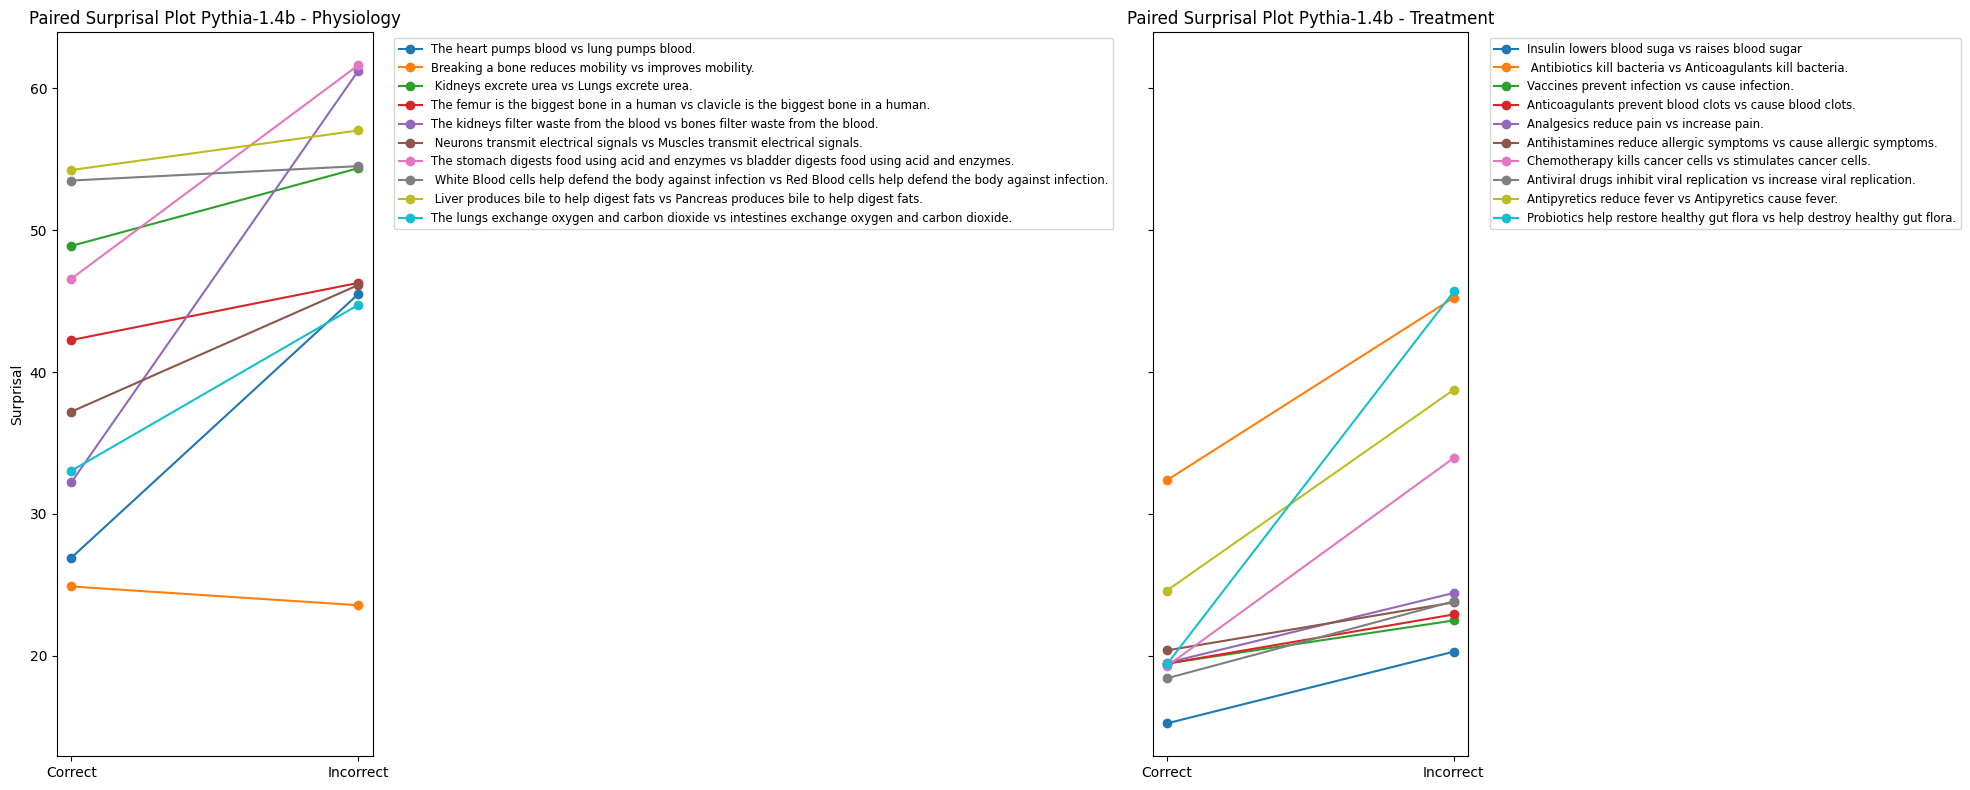

In [18]:
df_pythia = results_dfpythia

# Split categories
phy_data = df_pythia[df_pythia['category'] == 'Physiology']
treat_data = df_pythia[df_pythia['category'] == 'Treatment']

# Pivot
phy_pivot = phy_data.pivot(index='item_id', columns='condition', values='surprisal')
treat_pivot = treat_data.pivot(index='item_id', columns='condition', values='surprisal')

# Normalize column labels
phy_pivot.columns = phy_pivot.columns.str.lower().str.strip()
treat_pivot.columns = treat_pivot.columns.str.lower().str.strip()

# Prepare figure
fig, axes = plt.subplots(1, 2, figsize=(20, 8), sharey=True)

x = [0, 1]
labels = ['Correct', 'Incorrect']

#PHYSIOLOGY PLOT

axes[0].set_title('Paired Surprisal Plot Pythia-1.4b - Physiology')
axes[0].set_ylabel('Surprisal')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels)

for item_id, row in phy_pivot.iterrows():
    original = stimuli[item_id]
    label = (
        f"{original['seen']} "
        f"{original['correct_unseen'][:-1]} vs "
        f"{original['incorrect_unseen']}"
    )

    axes[0].plot(x, [row['correct'], row['incorrect']], marker='o', label=label)

axes[0].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')


#TREATMENT PLOT

axes[1].set_title('Paired Surprisal Plot Pythia-1.4b - Treatment')
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels)

for item_id, row in treat_pivot.iterrows():
    original = stimuli[item_id]
    label = (
        f"{original['seen']} "
        f"{original['correct_unseen'][:-1]} vs "
        f"{original['incorrect_unseen']}"
    )

    axes[1].plot(x, [row['correct'], row['incorrect']], marker='o', label=label)

axes[1].legend(loc='upper left', bbox_to_anchor=(1.05, 1), fontsize='small')

plt.tight_layout()
plt.show()

The graph above compares the possible outcomes for each individual statement in both the Physiology, and Treatment category for Pythia-1.4b. The results shown are more significant across both categories.

# Graph 2: Bar Chart

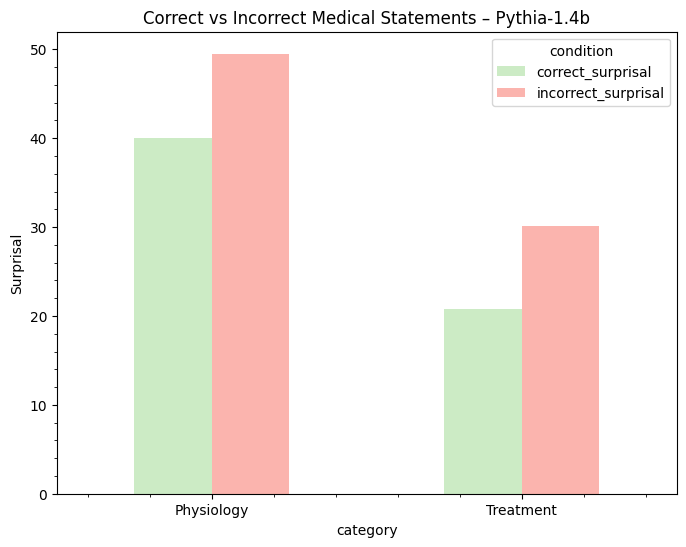

In [19]:
#putting results function into a bar chart

df = pd.DataFrame(result)
df_pythia = df.copy()
df_pythia['model'] = 'Pythia-1.4b'

# Pivot: one row per item
pivoted_df = df_pythia.pivot_table(
    index=['category','item_id'],
    columns='condition',
    values='surprisal'
).reset_index()

# Normalize and rename columns
pivoted_df.columns = pivoted_df.columns.str.lower().str.strip()
pivoted_df.rename(columns={'correct':'correct_surprisal', 'incorrect':'incorrect_surprisal'}, inplace=True)

# Now you can safely group and plot
category_means = pivoted_df.groupby('category')[['correct_surprisal','incorrect_surprisal']].mean()

# Plot
cmap = plt.get_cmap('Pastel1')
colors = cmap.colors

category_means.plot(
    kind='bar',
    color=[colors[2], colors[0]],
    figsize=(8,6)
)

plt.minorticks_on()
plt.ylabel('Surprisal')
plt.title('Correct vs Incorrect Medical Statements – Pythia-1.4b')
plt.xticks(rotation=0)
plt.show()

The graph above compares the surprisal rates of both averages of incorrect and correct statements in Physiology and Treatment, showing a significant difference between both categories.

## Analysis on Pythia-1.4B:

Pythia-1.4B demonstrates the clearest sensitivity to correct vs incorrect medical statements among the three models tests, showing consistent surprisal gaps in the expected direction across both the physiology, correct statements have a lower surprisal ~55 while incorrect ones have significantly higher ~64, and treatment statements, correct statements have a lower surprisal of ~32, and incorrect ones are higher ~37. This shows that the model has distributional familiarity with anatomy than treatments. Pythia is trained on The Pile, a large heterogeneous corpus, so the pattern suggests broad exposure to general factual language but still an, inconsistent exposure to specialized medical information.



The model could have encountered enough consistent text about anatomy and their functions to distinguish that the heart is associated with pumping blood and the lungs are associated with gas exchange. However, this representation is still associative and not explanatory. Pythia doesn't necessarily understand why these functions occur, nor can it generalize the reasoning beyond familiar patterns in the training corpus. This is why surprisal differences are present but are still modestly small even though it is more confident than earlier models. An observation I noted was that Pythia performance is similar between treatment and physiology. This highlights that scaling enables it to capture more consistent domain signals in areas like treatment which will have lower representation in general text. The model demonstrates a form of pattern completion reasoning, so it recognizes which statements fit comon textual patterns but not the underlying mechanisms, which reinforces ongoing concerns in AI saftey and helthcare applications.


## Comparision Between the Three Models: GPT-2, GPT-Neo, Pythia-1.4B

Pictured/Coded below will be all three charts along side for an easier visual comparison.

In [20]:
#df_all.columns.tolist()

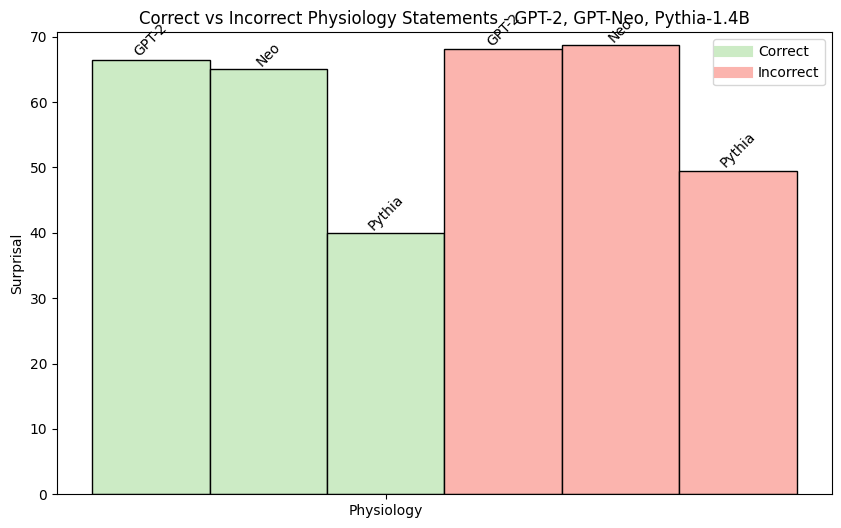

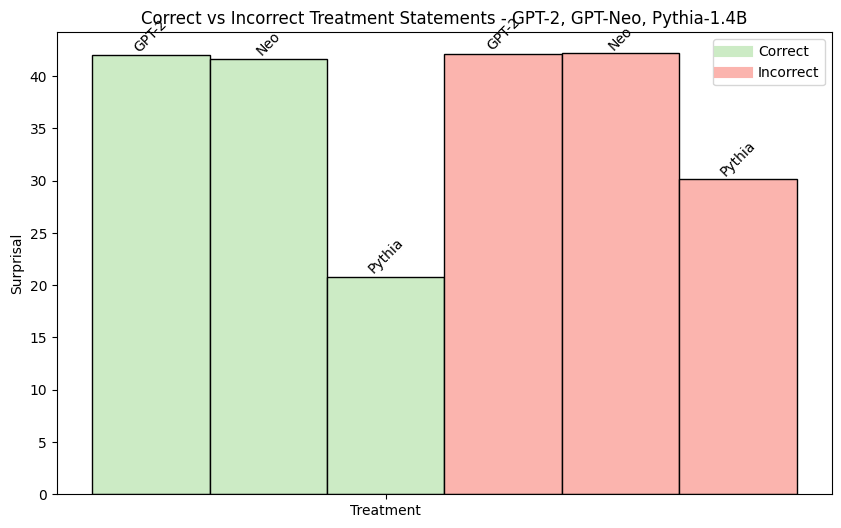

In [22]:
import numpy as np
#Creating the data, and attaching values to each category
df_all = pd.concat([df_gpt2, df_gptneo, df_pythia], ignore_index=True)


#getting values, first physiology then treatment
categories = ['Physiology','Treatment']
summary = (
    df_all
    .groupby(['model', 'category', 'condition'])['surprisal']
    .mean()
    .reset_index()
    .pivot(index=['model', 'category'],
           columns='condition',
           values='surprisal')
    .reset_index()
)
summary = summary.rename(columns={
    'Correct': 'correct_surprisal',
    'Incorrect': 'incorrect_surprisal'
})

summary
def get_values(model_name):
    sub = summary[summary['model']==model_name].copy()
    sub = sub.set_index('category')
    sub = sub.reindex(categories)
    correct_num = sub['correct_surprisal'].astype(float).values
    incorrect_num = sub['incorrect_surprisal'].astype(float).values
    return correct_num,incorrect_num

correct_gpt2, incorrect_gpt2 = get_values('GPT-2')
correct_gptneo, incorrect_gptneo = get_values('GPT-Neo')
correct_pythia, incorrect_pythia = get_values('Pythia-1.4b')

#Positioning the charts
x = 0
width = 0.13

#Pastel colors
cmap = plt.get_cmap('Pastel1')
colors = cmap.colors
green = colors[2]
red = colors[0]


# PHYSIOLOGY Graph
plt.figure(figsize=(10,6))

# Correct bars
plt.bar(x-2*width, [correct_gpt2[0]], width, color=green, edgecolor='black')
plt.bar(x-1*width, [correct_gptneo[0]], width, color=green, edgecolor='black')
plt.bar(x, [correct_pythia[0]], width, color=green, edgecolor='black')

# Incorrect bars
plt.bar(x+1*width, [incorrect_gpt2[0]], width, color=red, edgecolor='black')
plt.bar(x+2*width, [incorrect_gptneo[0]], width, color=red, edgecolor='black')
plt.bar(x+3*width, [incorrect_pythia[0]], width, color=red, edgecolor='black')

# BAR LABELS ABOVE EACH BAR
heights = [
    correct_gpt2[0], correct_gptneo[0], correct_pythia[0],
    incorrect_gpt2[0], incorrect_gptneo[0], incorrect_pythia[0]
]
bar_labels = [
    'GPT-2', 'Neo', 'Pythia',
    'GPT-2', 'Neo', 'Pythia'
]
for i, h in enumerate(heights):
    plt.text(x + (i-2)*width, h + 0.05, bar_labels[i],
             ha='center', va='bottom', rotation=45)

# Legend: ONLY correct/incorrect
correct_patch = plt.Line2D([0], [0], color=green, lw=8)
incorrect_patch = plt.Line2D([0], [0], color=red, lw=8)
plt.legend(handles=[correct_patch, incorrect_patch],
           labels=['Correct', 'Incorrect'])

plt.ylabel('Surprisal')
plt.title('Correct vs Incorrect Physiology Statements - GPT-2, GPT-Neo, Pythia-1.4B')
plt.xticks([x], ['Physiology'])
plt.ylim(0, max(heights) + 2)
plt.show()


# TREATMENT Graph
plt.figure(figsize=(10,6))

# Correct bars
plt.bar(x-2*width, [correct_gpt2[1]], width, color=green, edgecolor='black')
plt.bar(x-1*width, [correct_gptneo[1]], width, color=green, edgecolor='black')
plt.bar(x, [correct_pythia[1]], width, color=green, edgecolor='black')

# Incorrect bars
plt.bar(x+1*width, [incorrect_gpt2[1]], width, color=red, edgecolor='black')
plt.bar(x+2*width, [incorrect_gptneo[1]], width, color=red, edgecolor='black')
plt.bar(x+3*width, [incorrect_pythia[1]], width, color=red, edgecolor='black')

# BAR LABELS ABOVE EACH BAR
heights = [
    correct_gpt2[1], correct_gptneo[1], correct_pythia[1],
    incorrect_gpt2[1], incorrect_gptneo[1], incorrect_pythia[1]
]
bar_labels = [
    'GPT-2', 'Neo', 'Pythia',
    'GPT-2', 'Neo', 'Pythia'
]
for i, h in enumerate(heights):
    plt.text(x + (i-2)*width, h + 0.05, bar_labels[i],
             ha='center', va='bottom', rotation=45)

# Legend: ONLY correct/incorrect
correct_patch = plt.Line2D([0], [0], color=green, lw=8)
incorrect_patch = plt.Line2D([0], [0], color=red, lw=8)
plt.legend(handles=[correct_patch, incorrect_patch],
           labels=['Correct', 'Incorrect'])

plt.ylabel('Surprisal')
plt.title('Correct vs Incorrect Treatment Statements - GPT-2, GPT-Neo, Pythia-1.4B')
plt.xticks([x], ['Treatment'])
plt.ylim(0, max(heights) + 2)
plt.show()

Comparing the three models, there is clear progression in the models ability to represent medically coherent information, that reflects the broader scaling laws seen in LM research. Both GPT 2 and GPT Neo show small, inconsistent surprisal differences between correct and incorrect statements demonstrating that neither model has knowledge in physiological or treatment. Gpt 2 shows a bit of a higher surprisal for incorrect statements but nonetheless, the gap is still very small, suggesting reliance on simple frequency or co-occurence statistics than understanding. GPT Neo performs slightly better, though, sometimes still  assigning a lower surprisal to medically impossible statements, which could be due to its training on a noisy Pile dataset. GPT Neo is exposed to more heterogeneous mix of text so it may encounter patters where medically incorrect statements appear in contexts that reduce their unexpectedness. These models highlight that small/ medium sized LLMs can't reliably encode structured medical facts and rather instead depend on distributional familiarity.

In contrast Pythia 1.4B demonstrates the 'clearest' and most consistent differentation between incorrect and correct statements in both categories, showing that larger parameter counts produce stronger statistical representations of medical regularities. However, Pythia's surprisal gaps are still moderate, showing that its advantage is richer associative encoding instead of genuine casual understanding of the statements. While Pythia is better at detecting one statement is more typical than the other, the model does not know why this is true. All in all, the model comparison underscores that domain sensitivity in LLMs improves with scale but is still fundamentally limited without curated domain specific trainng.

## Additional Testing: Chat GPT 5.1

In this additional testing, I will be putting in my minimal pairs into Chat GPT 5.1 since using the 2XL model is too big to run on my computer. I will be directly putting the pair into the chat and prompting it to assign which is the correct pair. I believe that there will be a greater distinction in this model in comparison to the previous three I used, since it has a greater database.

Inserted below is the prompt and context I gave into the model, and the first minimal pairs with the models response.

![Screenshot_9-12-2025_203735_chatgpt.com.jpeg]()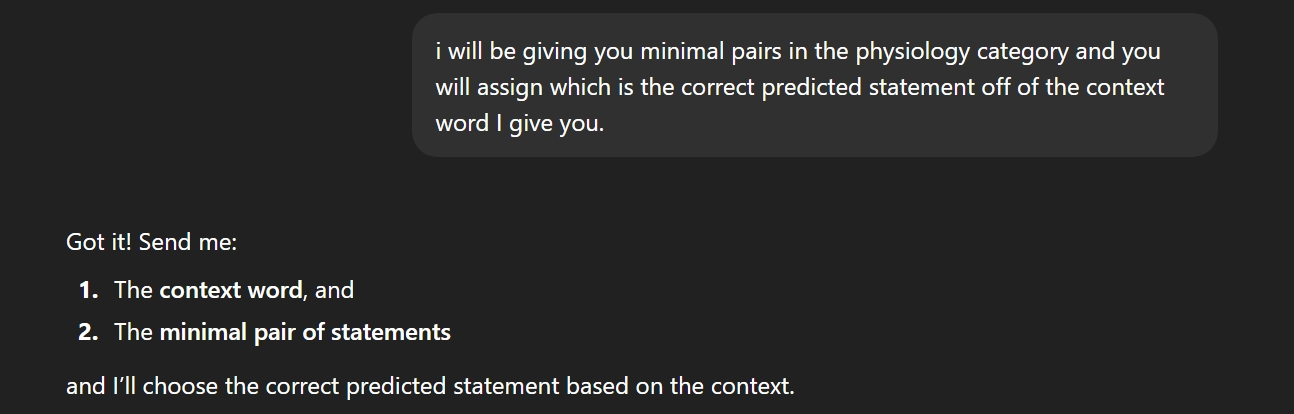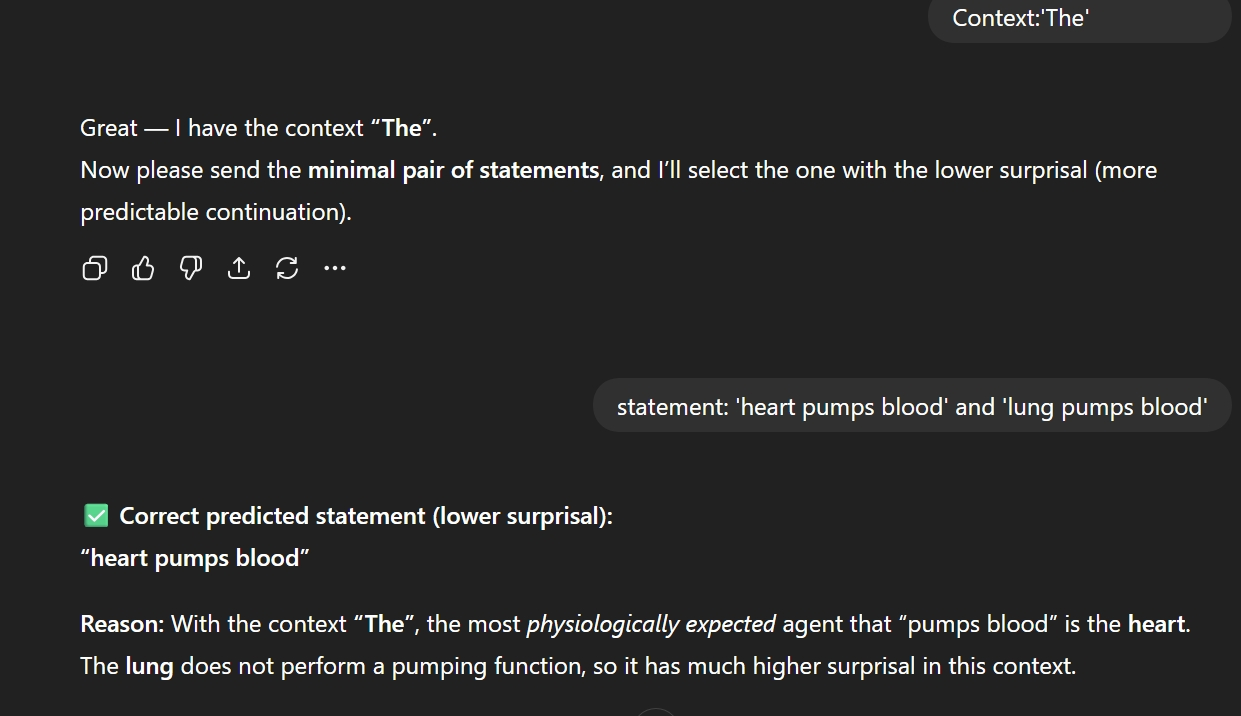

Inserted below is a table summerizing the results from having GPT 5.1 access the 20 minimal pairs: 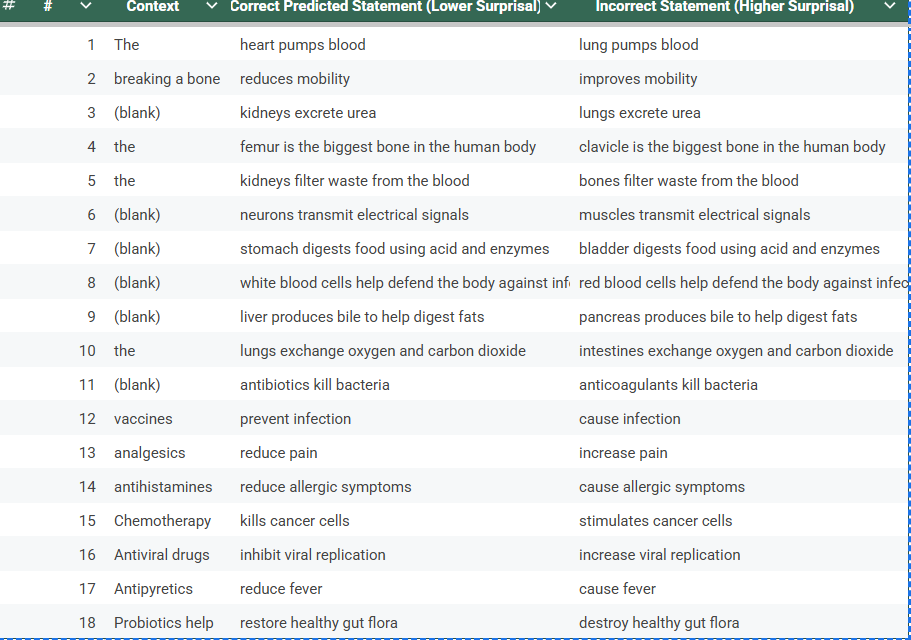




Overall, the model was able to detect the correct statement, showing a high incorrect surprisal rate compared to the smaller models I tested. The surprisal rates remained consistent across the treatment category, indicating that the smaller models still lack substantial knowledge in that area. GPT-5.1, however, was able to strongly differentiate between the two statements and showed a greater difference in surprisal rates.  



## Conclusion:

To conclude this project, results show that surprisal values across physiology and treatment statements demonstrate that LLMs typically assign lower surprisal to correct statements compared to incorrect ones. GPT-Neo and Pythia consistently reflect this pattern for physiology, where the difference between correct and incorrect statements is most clear, highlighting stronger confidence in topics related to physiology. GPT-2 demonstrated a few inconsistencies in physiology and occasionally assigned lower surprisal to correcr statements, revealing possible domain-specific limitations. Regarding treatment statements, it exhibited lower surprisal values across all Models suggest that they found treatment-related statements more challenging. GPT-5.1, however, was able to more strongly differentiate between correct and incorrect statements and showed greater differences in surprisal rates, indicating improved domain knowledge and confidence. Overall, these results show that while language models can differentiate correct from incorrect medical statements to some extent, smaller models still struggle, whereas GPT-5.1 demonstrates noticeably stronger performance. This highlights a key trend that medical reasoning in LLMs isproves with scale, but smaller models still struggle to encode structured, causally coherent medical knowledge